# GraphSAGE Ranking Only Pipeline

This version keeps the full original data loading, EDA, preprocessing, splitting, graph construction, and training/evaluation infrastructure.

Only the non-GraphSAGE model sections were removed:

- Two-Tower MLP
- LightGCN
- Matrix Factorization

Main experiment focus:

- GraphSAGE
- BPR ranking loss
- Recall@K
- NDCG@K
- Adjustable K-core filtering


# Amazon Musical Instruments Recommendation System - Data Loading & EDA

Graph Neural Network Based Recommendation System Project

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import gzip

# import matplotlib
# matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
# print(matplotlib.get_backend())

import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Libraries imported successfully!")

PyTorch version: 1.13.0
CUDA available: True
Using device: cuda
Libraries imported successfully!


---

## 2. Data Loading

### 2.1 Load Ratings Data

In [2]:
# Load ratings data
ratings_df = pd.read_csv('data/ratings_Books.csv', 
                         names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"Ratings data shape: {ratings_df.shape}")
print(f"\nFirst 5 rows:")
display(ratings_df.head())

Ratings data shape: (22507155, 4)

First 5 rows:


,user_id,item_id,rating,timestamp
0,AH2L9G3DQHHAJ,0000000116,4.0,1019865600
1,A2IIIDRK3PRRZY,0000000116,1.0,1395619200
2,A1TADCM7YWPQ8M,0000000868,4.0,1031702400
3,AWGH7V0BDOJKB,0000013714,4.0,1383177600
4,A3UTQPQPM4TQO0,0000013714,5.0,1374883200


### 2.2 Load Reviews Data

In [3]:
# Load reviews data
def load_json_gz(file_path, max_rows=1_000_000, min_rating=4.0):
    """Load compressed JSON file (handles both JSON and Python dict format)"""
    import ast
    data = []

    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            if idx >= max_rows:
                break

            line = line.strip()
            if not line:
                continue

            try:
                # Try standard JSON first
                row = json.loads(line)
            except json.JSONDecodeError:
                # If that fails, try using ast.literal_eval for Python dict format
                try:
                    row = ast.literal_eval(line)
                except:
                    # Skip malformed lines
                    continue

            # Keep only required fields for memory efficiency
            reviewer = row.get("reviewerID")
            asin = row.get("asin")
            rating = row.get("overall")

            if reviewer is None or asin is None or rating is None:
                continue

            # Optional positive-rating filtering
            if min_rating is not None and rating < min_rating:
                continue

            data.append({
                "reviewerID": reviewer,
                "asin": asin,
                "overall": rating
            })

    return pd.DataFrame(data)


reviews_df = load_json_gz(
    'data/reviews_Books.json.gz',
    max_rows=1_000_000,
    min_rating=4.0
)

print(f"Reviews data shape: {reviews_df.shape}")
print(f"\nColumn names: {reviews_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(reviews_df.head(3))

Reviews data shape: (800644, 3)

Column names: ['reviewerID', 'asin', 'overall']

First 3 rows:


,reviewerID,asin,overall
0,AH2L9G3DQHHAJ,0000000116,4.0
1,A1TADCM7YWPQ8M,0000000868,4.0
2,AWGH7V0BDOJKB,0000013714,4.0


### 2.3 Load Product Metadata

In [4]:
# Load product metadata
meta_df = load_json_gz(
    'data/meta_Books.json.gz',
    max_rows=500_000,
    min_rating=None
)

# For metadata files, records may not contain review fields.
# Reload full rows if filtered output is empty.
if meta_df.empty:
    def load_meta_json_gz(file_path, max_rows=500_000):
        """Load compressed metadata JSON file"""
        import ast
        data = []

        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if idx >= max_rows:
                    break

                line = line.strip()
                if not line:
                    continue

                try:
                    row = json.loads(line)
                except json.JSONDecodeError:
                    try:
                        row = ast.literal_eval(line)
                    except:
                        continue

                data.append({
                    "asin": row.get("asin"),
                    "title": row.get("title"),
                    "category": row.get("category"),
                    "price": row.get("price"),
                    "brand": row.get("brand")
                })

        return pd.DataFrame(data)

    meta_df = load_meta_json_gz('data/meta_Books.json.gz', max_rows=500_000)

print(f"Metadata shape: {meta_df.shape}")
print(f"\nColumn names: {meta_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(meta_df.head(3))

Metadata shape: (500000, 5)

Column names: ['asin', 'title', 'category', 'price', 'brand']

First 3 rows:


,asin,title,category,price,brand
0,0001048791,"The Crucible: Performed by Stuart Pankin, Jero...",None,NaN,None
1,0001048775,Measure for Measure: Complete &amp; Unabridged,None,NaN,None
2,0001048236,The Sherlock Holmes Audio Collection,None,9.26,None


---

## 3. Basic Data Statistics

### 3.1 Ratings Data Statistics

In [5]:
print("=" * 60)
print("Ratings Data Basic Statistics")
print("=" * 60)

print(f"\nTotal interactions: {len(ratings_df):,}")
print(f"Unique users: {ratings_df['user_id'].nunique():,}")
print(f"Unique items: {ratings_df['item_id'].nunique():,}")
print(f"Data sparsity: {(1 - len(ratings_df) / (ratings_df['user_id'].nunique() * ratings_df['item_id'].nunique())) * 100:.4f}%")

print(f"\nRating statistics:")
print(ratings_df['rating'].describe())

print(f"\nData types:")
print(ratings_df.dtypes)

print(f"\nMissing values:")
print(ratings_df.isnull().sum())

Ratings Data Basic Statistics

Total interactions: 22,507,155
Unique users: 8,026,324
Unique items: 2,330,066
Data sparsity: 99.9999%

Rating statistics:
count    2.250716e+07
mean     4.295759e+00
std      1.111507e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Data types:
user_id       object
item_id       object
rating       float64
timestamp      int64
dtype: object

Missing values:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


### 3.2 Reviews Data Statistics

In [6]:
print("=" * 60)
print("Reviews Data Basic Statistics")
print("=" * 60)

print(f"\nTotal reviews: {len(reviews_df):,}")
print(f"\nData types:")
print(reviews_df.dtypes)

print(f"\nMissing values statistics:")
missing_stats = reviews_df.isnull().sum()
missing_pct = (missing_stats / len(reviews_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_stats,
    'Missing Percentage (%)': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Reviews Data Basic Statistics

Total reviews: 800,644

Data types:
reviewerID     object
asin           object
overall       float64
dtype: object

Missing values statistics:
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


### 3.3 Product Metadata Statistics

In [7]:
print("=" * 60)
print("Product Metadata Basic Statistics")
print("=" * 60)

print(f"\nTotal products: {len(meta_df):,}")
print(f"\nData types:")
print(meta_df.dtypes)

print(f"\nMissing values statistics:")
missing_stats = meta_df.isnull().sum()
missing_pct = (missing_stats / len(meta_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_stats,
    'Missing Percentage (%)': missing_pct
})
print(missing_df)

Product Metadata Basic Statistics

Total products: 500,000

Data types:
asin         object
title        object
category     object
price       float64
brand        object
dtype: object

Missing values statistics:
          Missing Count  Missing Percentage (%)
asin                  0                    0.00
title               261                    0.05
category         500000                  100.00
price            115985                   23.20
brand            499978                  100.00


### 3.4 Data Quality Analysis

#### 3.4.1 Missing Values Analysis

MISSING VALUES ANALYSIS

1. RATINGS DATA:
----------------------------------------
✓ No missing values found in ratings data

2. REVIEWS DATA:
----------------------------------------
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []

3. METADATA:
----------------------------------------
          Missing Count  Percentage (%)
title               261            0.05
category         500000          100.00
price            115985           23.20
brand            499978          100.00


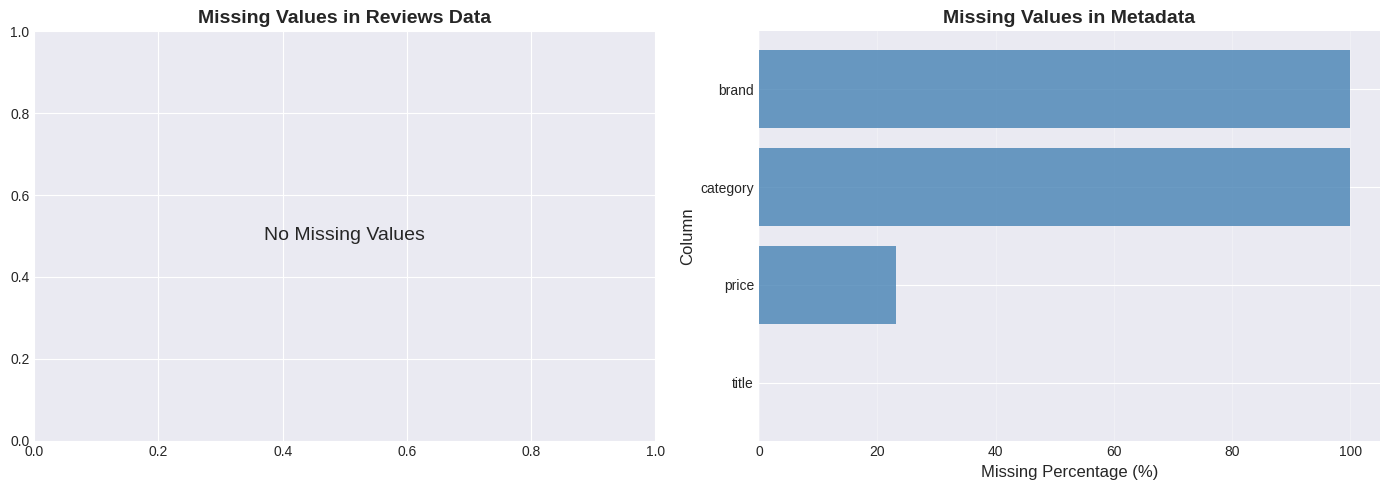

In [8]:
# Comprehensive missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

print("\n1. RATINGS DATA:")
print("-" * 40)
ratings_missing = ratings_df.isnull().sum()
if ratings_missing.sum() == 0:
    print("✓ No missing values found in ratings data")
else:
    print(ratings_missing[ratings_missing > 0])

print("\n2. REVIEWS DATA:")
print("-" * 40)
reviews_missing = reviews_df.isnull().sum()
reviews_missing_pct = (reviews_missing / len(reviews_df) * 100).round(2)
reviews_missing_summary = pd.DataFrame({
    'Missing Count': reviews_missing,
    'Percentage (%)': reviews_missing_pct
})
print(reviews_missing_summary[reviews_missing_summary['Missing Count'] > 0])

print("\n3. METADATA:")
print("-" * 40)
meta_missing = meta_df.isnull().sum()
meta_missing_pct = (meta_missing / len(meta_df) * 100).round(2)
meta_missing_summary = pd.DataFrame({
    'Missing Count': meta_missing,
    'Percentage (%)': meta_missing_pct
})
print(meta_missing_summary[meta_missing_summary['Missing Count'] > 0])

# # Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews missing values
reviews_missing_plot = reviews_missing_summary[reviews_missing_summary['Missing Count'] > 0].sort_values('Percentage (%)', ascending=True)
if len(reviews_missing_plot) > 0:
    axes[0].barh(reviews_missing_plot.index, reviews_missing_plot['Percentage (%)'], color='coral', alpha=0.8)
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_ylabel('Column', fontsize=12)
    axes[0].set_title('Missing Values in Reviews Data', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Reviews Data', fontsize=14, fontweight='bold')

# Metadata missing values
meta_missing_plot = meta_missing_summary[meta_missing_summary['Missing Count'] > 0].sort_values('Percentage (%)', ascending=True)
if len(meta_missing_plot) > 0:
    axes[1].barh(meta_missing_plot.index, meta_missing_plot['Percentage (%)'], color='steelblue', alpha=0.8)
    axes[1].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[1].set_ylabel('Column', fontsize=12)
    axes[1].set_title('Missing Values in Metadata', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Values in Metadata', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.4.2 Duplicate Values Analysis

DUPLICATE VALUES ANALYSIS

1. RATINGS DATA:
----------------------------------------
Exact duplicate rows: 0 (0.00%)
Duplicate user-item pairs: 0 (0.00%)
Duplicate user-item-rating combinations: 0 (0.00%)

2. REVIEWS DATA:
----------------------------------------
Exact duplicate rows (hashable columns only): 0 (0.00%)

3. METADATA:
----------------------------------------
Exact duplicate rows (hashable columns only): 0 (0.00%)


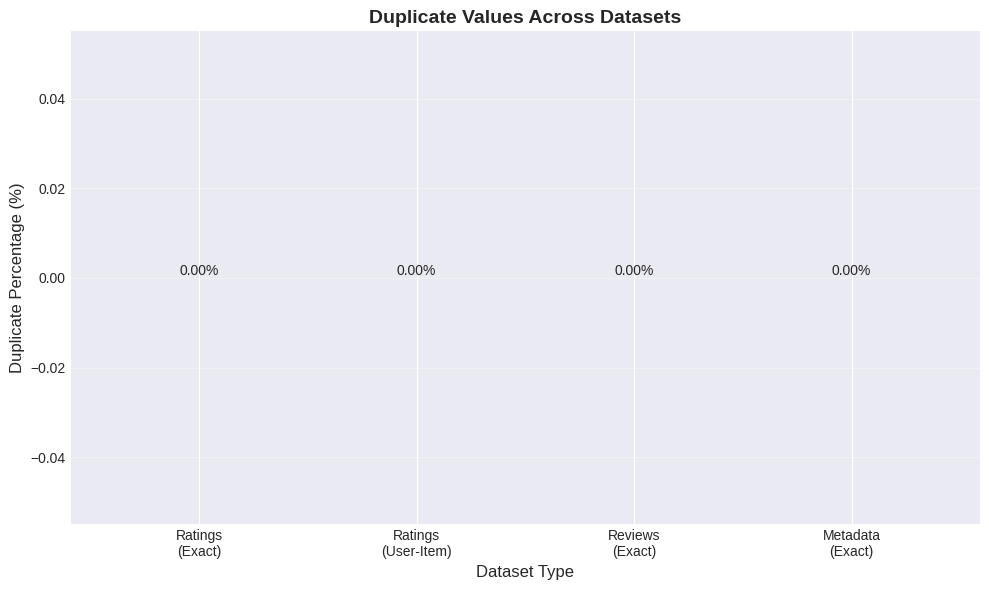

In [9]:
# Comprehensive duplicate values analysis
print("=" * 80)
print("DUPLICATE VALUES ANALYSIS")
print("=" * 80)

print("\n1. RATINGS DATA:")
print("-" * 40)
# Check for exact duplicates
ratings_exact_dup = ratings_df.duplicated().sum()
print(f"Exact duplicate rows: {ratings_exact_dup:,} ({ratings_exact_dup/len(ratings_df)*100:.2f}%)")

# Check for duplicate user-item pairs
ratings_user_item_dup = ratings_df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Duplicate user-item pairs: {ratings_user_item_dup:,} ({ratings_user_item_dup/len(ratings_df)*100:.2f}%)")

# Check for duplicate user-item-rating combinations
ratings_user_item_rating_dup = ratings_df.duplicated(subset=['user_id', 'item_id', 'rating']).sum()
print(f"Duplicate user-item-rating combinations: {ratings_user_item_rating_dup:,} ({ratings_user_item_rating_dup/len(ratings_df)*100:.2f}%)")

# Show examples if duplicates exist
if ratings_user_item_dup > 0:
    print("\nExample of duplicate user-item pairs:")
    dup_mask = ratings_df.duplicated(subset=['user_id', 'item_id'], keep=False)
    dup_examples = ratings_df[dup_mask].sort_values(['user_id', 'item_id']).head(10)
    print(dup_examples)

print("\n2. REVIEWS DATA:")
print("-" * 40)
# Only check hashable columns (exclude lists, dicts, etc.)
hashable_cols = []
for col in reviews_df.columns:
    try:
        # Try to hash the first non-null value
        sample = reviews_df[col].dropna().iloc[0] if len(reviews_df[col].dropna()) > 0 else None
        if sample is not None:
            hash(sample)
        hashable_cols.append(col)
    except (TypeError, AttributeError):
        # Skip unhashable columns
        pass

if len(hashable_cols) > 0:
    reviews_exact_dup = reviews_df[hashable_cols].duplicated().sum()
    print(f"Exact duplicate rows (hashable columns only): {reviews_exact_dup:,} ({reviews_exact_dup/len(reviews_df)*100:.2f}%)")
else:
    reviews_exact_dup = 0
    print("Cannot check for exact duplicates (no hashable columns)")

# Check for duplicate reviewerID-item_id pairs if columns exist
if 'reviewerID' in reviews_df.columns and 'item_id' in reviews_df.columns:
    reviews_user_item_dup = reviews_df.duplicated(subset=['reviewerID', 'item_id']).sum()
    print(f"Duplicate reviewer-product pairs: {reviews_user_item_dup:,} ({reviews_user_item_dup/len(reviews_df)*100:.2f}%)")
    
    if reviews_user_item_dup > 0:
        print("\nExample of duplicate reviewer-product pairs:")
        dup_mask = reviews_df.duplicated(subset=['reviewerID', 'item_id'], keep=False)
        dup_examples = reviews_df[dup_mask].sort_values(['reviewerID', 'item_id'])[['reviewerID', 'item_id', 'overall']].head(10)
        print(dup_examples)
else:
    reviews_user_item_dup = 0

print("\n3. METADATA:")
print("-" * 40)
# Only check hashable columns for metadata
meta_hashable_cols = []
for col in meta_df.columns:
    try:
        sample = meta_df[col].dropna().iloc[0] if len(meta_df[col].dropna()) > 0 else None
        if sample is not None:
            hash(sample)
        meta_hashable_cols.append(col)
    except (TypeError, AttributeError):
        pass

if len(meta_hashable_cols) > 0:
    meta_exact_dup = meta_df[meta_hashable_cols].duplicated().sum()
    print(f"Exact duplicate rows (hashable columns only): {meta_exact_dup:,} ({meta_exact_dup/len(meta_df)*100:.2f}%)")
else:
    meta_exact_dup = 0
    print("Cannot check for exact duplicates (no hashable columns)")

# Check for duplicate item_ids
if 'item_id' in meta_df.columns:
    meta_item_id_dup = meta_df.duplicated(subset=['item_id']).sum()
    print(f"Duplicate item_ids: {meta_item_id_dup:,} ({meta_item_id_dup/len(meta_df)*100:.2f}%)")
    
    if meta_item_id_dup > 0:
        print("\nExample of duplicate item_ids:")
        dup_mask = meta_df.duplicated(subset=['item_id'], keep=False)
        dup_examples = meta_df[dup_mask].sort_values('item_id')[['item_id', 'title', 'brand']].head(10)
        print(dup_examples)
else:
    meta_item_id_dup = 0

# Visualize duplicates
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

duplicate_summary = {
    'Ratings\n(Exact)': ratings_exact_dup / len(ratings_df) * 100,
    'Ratings\n(User-Item)': ratings_user_item_dup / len(ratings_df) * 100,
    'Reviews\n(Exact)': reviews_exact_dup / len(reviews_df) * 100,
    'Metadata\n(Exact)': meta_exact_dup / len(meta_df) * 100
}

if 'item_id' in meta_df.columns:
    duplicate_summary['Metadata\n(item_id)'] = meta_item_id_dup / len(meta_df) * 100

if 'reviewerID' in reviews_df.columns and 'item_id' in reviews_df.columns:
    duplicate_summary['Reviews\n(User-Item)'] = reviews_user_item_dup / len(reviews_df) * 100

categories = list(duplicate_summary.keys())
values = list(duplicate_summary.values())

bars = ax.bar(categories, values, color=['steelblue', 'coral', 'green', 'orange', 'purple'][:len(categories)], alpha=0.8)
ax.set_ylabel('Duplicate Percentage (%)', fontsize=12)
ax.set_xlabel('Dataset Type', fontsize=12)
ax.set_title('Duplicate Values Across Datasets', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Rating Distribution

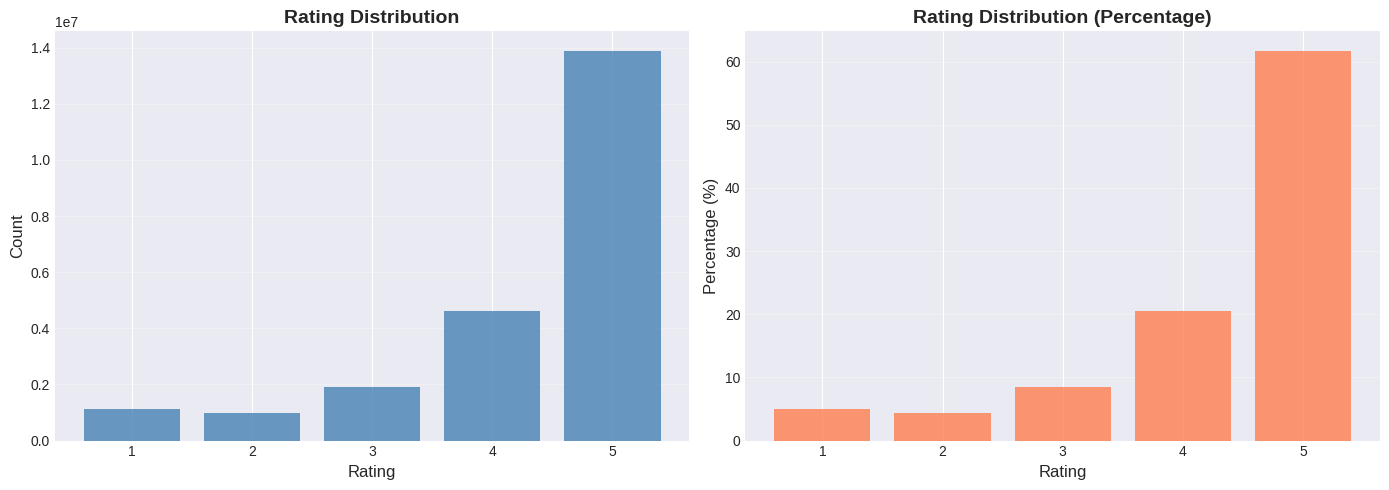


Rating distribution:
        Count  Percentage (%)
1.0   1116862            4.96
2.0    978560            4.35
3.0   1922390            8.54
4.0   4602555           20.45
5.0  13886788           61.70


In [10]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = ratings_df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
rating_pct = (rating_counts / len(ratings_df) * 100).round(2)
axes[1].bar(rating_pct.index, rating_pct.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Rating Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRating distribution:")
print(pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct}))

### 4.2 User Activity Analysis

User Activity Statistics:
Mean interactions per user: 2.80
Median interactions per user: 1.00
Max interactions per user: 43201
Min interactions per user: 1


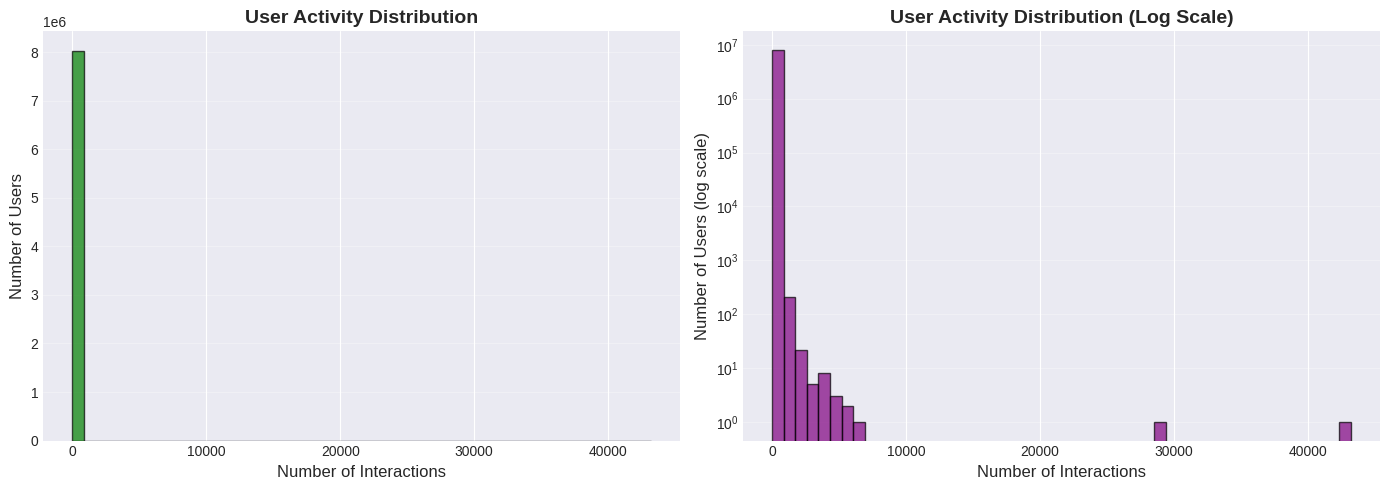


Top 10 most active users:
user_id
A14OJS0VWMOSWO    43201
AFVQZQ8PW0L       28816
A2F6N60Z96CAJI     6121
A320TMDV6KCFU      5955
A2OJW07GQRNJUT     5443
A328S9RN3U5M68     5031
A1S3C5OFU508P3     4599
A13QTZ8CIMHHG4     4564
A1X8VZWTOG8IS6     4050
AHD101501WCN1      4044
dtype: int64


In [11]:
# User activity statistics
user_activity = ratings_df.groupby('user_id').size()

print("User Activity Statistics:")
print(f"Mean interactions per user: {user_activity.mean():.2f}")
print(f"Median interactions per user: {user_activity.median():.2f}")
print(f"Max interactions per user: {user_activity.max()}")
print(f"Min interactions per user: {user_activity.min()}")

# Visualize user activity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(user_activity, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Interactions', fontsize=12)
axes[0].set_ylabel('Number of Users', fontsize=12)
axes[0].set_title('User Activity Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Log scale histogram
axes[1].hist(user_activity, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Interactions', fontsize=12)
axes[1].set_ylabel('Number of Users (log scale)', fontsize=12)
axes[1].set_title('User Activity Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top active users
print("\nTop 10 most active users:")
print(user_activity.sort_values(ascending=False).head(10))

### 4.3 Item Popularity Analysis

Item Popularity Statistics:
Mean interactions per item: 9.66
Median interactions per item: 2.00
Max interactions per item: 21398
Min interactions per item: 1


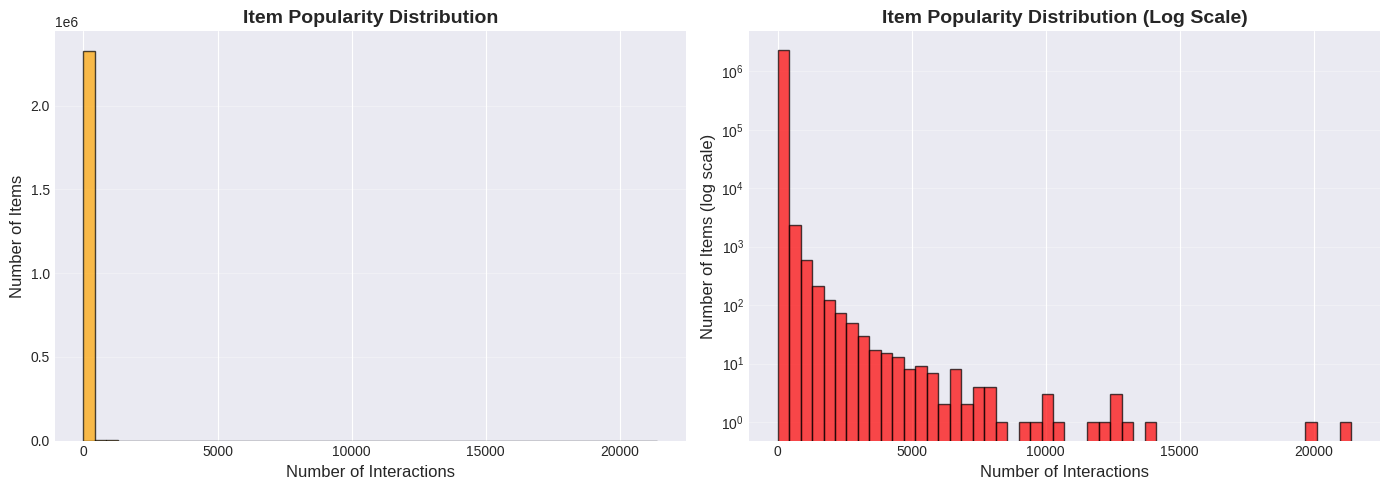


Top 10 most popular items:
item_id
0439023483    21398
030758836X    19867
0439023513    14114
0385537859    12973
0007444117    12629
0375831002    12571
038536315X    12564
0345803485    12290
0316055433    11746
0849922070    10424
dtype: int64


In [12]:
# Item popularity statistics
item_popularity = ratings_df.groupby('item_id').size()

print("Item Popularity Statistics:")
print(f"Mean interactions per item: {item_popularity.mean():.2f}")
print(f"Median interactions per item: {item_popularity.median():.2f}")
print(f"Max interactions per item: {item_popularity.max()}")
print(f"Min interactions per item: {item_popularity.min()}")

# Visualize item popularity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(item_popularity, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Interactions', fontsize=12)
axes[0].set_ylabel('Number of Items', fontsize=12)
axes[0].set_title('Item Popularity Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Log scale histogram
axes[1].hist(item_popularity, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Interactions', fontsize=12)
axes[1].set_ylabel('Number of Items (log scale)', fontsize=12)
axes[1].set_title('Item Popularity Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top popular items
print("\nTop 10 most popular items:")
print(item_popularity.sort_values(ascending=False).head(10))

### 4.4 Temporal Analysis

Temporal Statistics:
Date range: 1996-05-20 00:00:00 to 2014-07-23 00:00:00
Time span: 6638 days


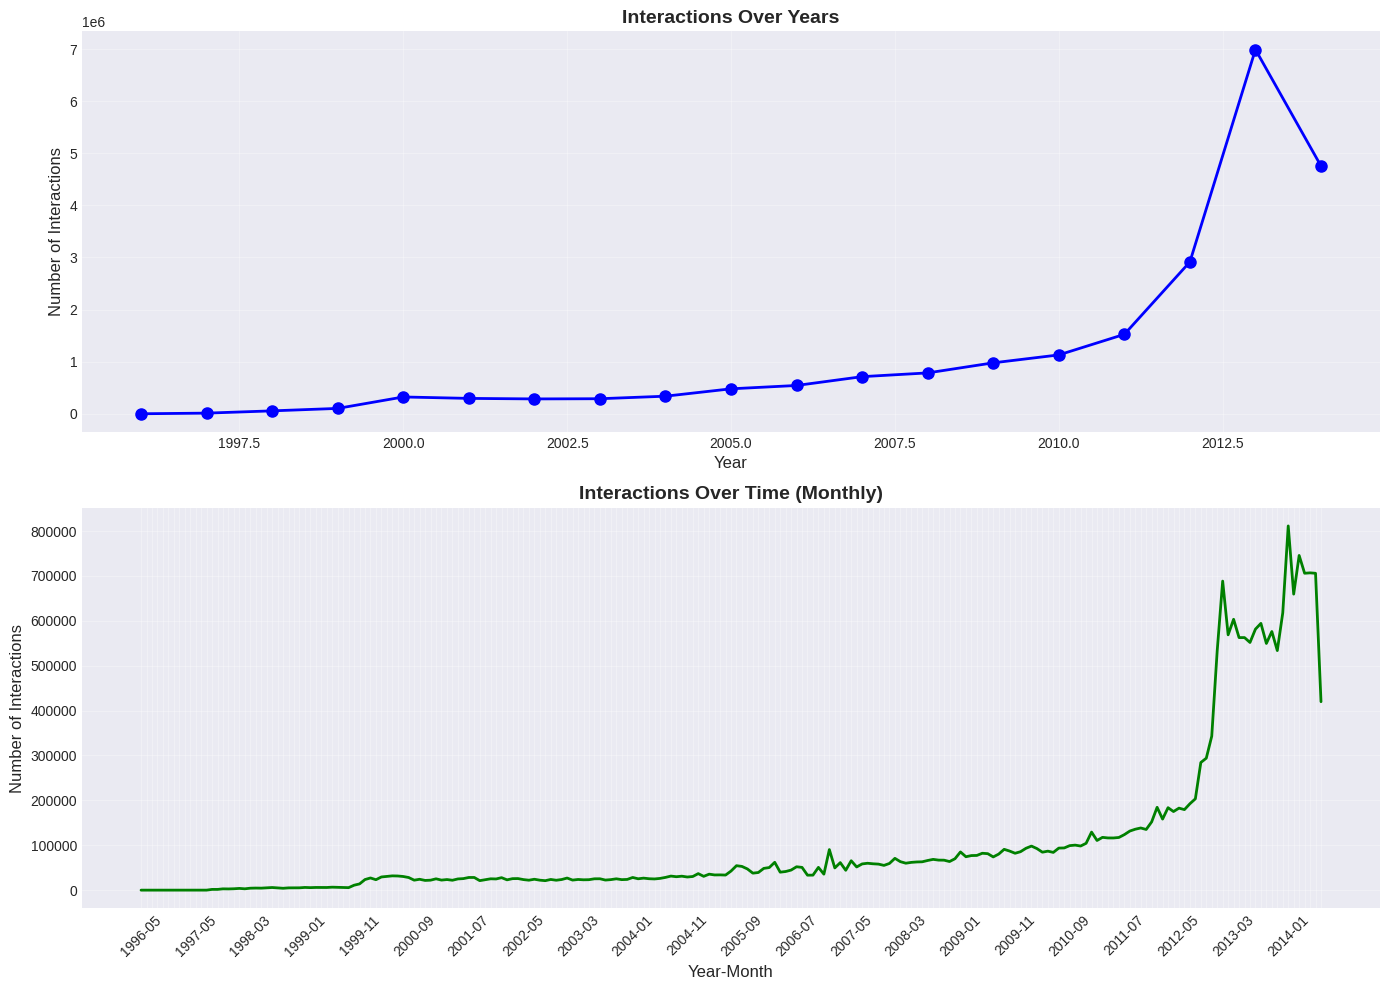

In [13]:
# Convert timestamp to datetime
ratings_df['datetime'] = pd.to_datetime(ratings_df['timestamp'], unit='s')
ratings_df['year'] = ratings_df['datetime'].dt.year
ratings_df['month'] = ratings_df['datetime'].dt.month
ratings_df['year_month'] = ratings_df['datetime'].dt.to_period('M')

print("Temporal Statistics:")
print(f"Date range: {ratings_df['datetime'].min()} to {ratings_df['datetime'].max()}")
print(f"Time span: {(ratings_df['datetime'].max() - ratings_df['datetime'].min()).days} days")

# Interactions over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# By year
yearly_counts = ratings_df['year'].value_counts().sort_index()
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Interactions', fontsize=12)
axes[0].set_title('Interactions Over Years', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# By month (aggregated)
monthly_counts = ratings_df.groupby('year_month').size()
axes[1].plot(monthly_counts.index.astype(str), monthly_counts.values, linewidth=2, color='green')
axes[1].set_xlabel('Year-Month', fontsize=12)
axes[1].set_ylabel('Number of Interactions', fontsize=12)
axes[1].set_title('Interactions Over Time (Monthly)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Show only every nth label to avoid crowding
n = max(1, len(monthly_counts) // 20)
for i, label in enumerate(axes[1].xaxis.get_ticklabels()):
    if i % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

### 4.5 Reviews Text Analysis

In [14]:
# Review text length analysis
if 'reviewText' in reviews_df.columns:
    reviews_df['review_length'] = reviews_df['reviewText'].fillna('').apply(len)
    reviews_df['review_word_count'] = reviews_df['reviewText'].fillna('').apply(lambda x: len(x.split()))
    
    print("Review Text Statistics:")
    print(f"Mean review length (characters): {reviews_df['review_length'].mean():.2f}")
    print(f"Mean review word count: {reviews_df['review_word_count'].mean():.2f}")
    print(f"Median review length (characters): {reviews_df['review_length'].median():.2f}")
    print(f"Median review word count: {reviews_df['review_word_count'].median():.2f}")
    
    # Visualize review length distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(reviews_df['review_length'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Review Length (characters)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    axes[1].hist(reviews_df['review_word_count'], bins=50, color='navy', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Review Word Count', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Review Word Count Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No reviewText column found in reviews data")

No reviewText column found in reviews data


### 4.6 Product Categories Analysis

In [15]:
# Analyze product categories
if 'categories' in meta_df.columns:
    # Extract all categories
    all_categories = []
    for cats in meta_df['categories'].dropna():
        if isinstance(cats, list):
            for cat_list in cats:
                if isinstance(cat_list, list):
                    all_categories.extend(cat_list)
    
    category_counts = Counter(all_categories)
    
    print(f"Total unique categories: {len(category_counts)}")
    print("\nTop 15 categories:")
    top_categories = pd.DataFrame(category_counts.most_common(15), 
                                  columns=['Category', 'Count'])
    print(top_categories)
    
    # Visualize top categories
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_categories)), top_categories['Count'], color='skyblue', alpha=0.8)
    plt.yticks(range(len(top_categories)), top_categories['Category'])
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.title('Top 15 Product Categories', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No categories column found in metadata")

No categories column found in metadata


---

## 5. Data Summary

In [16]:
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

summary = {
    'Metric': [
        'Total Interactions',
        'Unique Users',
        'Unique Items',
        'Data Sparsity (%)',
        'Avg Interactions per User',
        'Avg Interactions per Item',
        'Rating Range',
        'Most Common Rating',
        'Total Reviews',
        'Total Products in Metadata'
    ],
    'Value': [
        f"{len(ratings_df):,}",
        f"{ratings_df['user_id'].nunique():,}",
        f"{ratings_df['item_id'].nunique():,}",
        f"{(1 - len(ratings_df) / (ratings_df['user_id'].nunique() * ratings_df['item_id'].nunique())) * 100:.4f}",
        f"{user_activity.mean():.2f}",
        f"{item_popularity.mean():.2f}",
        f"{ratings_df['rating'].min()} - {ratings_df['rating'].max()}",
        f"{ratings_df['rating'].mode()[0]}",
        f"{len(reviews_df):,}",
        f"{len(meta_df):,}"
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print("=" * 80)

DATASET SUMMARY
                    Metric      Value
        Total Interactions 22,507,155
              Unique Users  8,026,324
              Unique Items  2,330,066
         Data Sparsity (%)    99.9999
 Avg Interactions per User       2.80
 Avg Interactions per Item       9.66
              Rating Range  1.0 - 5.0
        Most Common Rating        5.0
             Total Reviews    800,644
Total Products in Metadata    500,000


---

---

# PART 2: MODEL IMPLEMENTATION

## 6. Data Preprocessing for Models

### 6.1 Import Libraries and Setup

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 1.13.0
CUDA available: True
Using device: cuda


### 6.2 Data Filtering and Splitting

In [18]:
# ============================================================
# Ranking configuration
# ============================================================
# Main knobs for the ranking version of this pipeline.
# Change K_CORE to run k-core ablations, e.g. 0, 3, 5, 10.
K_CORE = 15

# Top-K for ranking evaluation.
# Change this to evaluate Recall@5/NDCG@5, Recall@10/NDCG@10, etc.
TOP_K = 20

# If you want to treat only high ratings as positive implicit feedback,
# set MIN_POSITIVE_RATING = 4.0.
# If None, every observed interaction is treated as positive feedback.
MIN_POSITIVE_RATING = 4.0

print(f"Ranking setup: K_CORE={K_CORE}, TOP_K={TOP_K}, MIN_POSITIVE_RATING={MIN_POSITIVE_RATING}")


# Filter users and items with minimum interactions (k-core filtering)
def filter_kcore(df, k=5):
    """
    Iteratively filter users and items with at least k interactions.
    If k <= 0, no k-core filtering is applied.
    """
    df = df.copy()

    if k is None or k <= 0:
        print("\nSkipping k-core filtering because k <= 0.")
        print(f"Data kept: {len(df)} interactions, {df['user_id'].nunique()} users, {df['item_id'].nunique()} items")
        return df.reset_index(drop=True)

    print(f"\nApplying {k}-core filtering...")
    print(f"Original: {len(df)} interactions, {df['user_id'].nunique()} users, {df['item_id'].nunique()} items")

    while True:
        before = len(df)

        user_counts = df['user_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        df = df[df['user_id'].isin(valid_users)]

        item_counts = df['item_id'].value_counts()
        valid_items = item_counts[item_counts >= k].index
        df = df[df['item_id'].isin(valid_items)]

        after = len(df)
        if after == before:
            break

    print(f"After filtering: {len(df)} interactions, {df['user_id'].nunique()} users, {df['item_id'].nunique()} items")
    return df.reset_index(drop=True)


# Optional: convert explicit ratings into implicit positive interactions.
ratings_for_ranking = ratings_df.copy()
if MIN_POSITIVE_RATING is not None:
    ratings_for_ranking = ratings_for_ranking[ratings_for_ranking['rating'] >= MIN_POSITIVE_RATING].copy()
    print(f"\nAfter rating threshold >= {MIN_POSITIVE_RATING}: {len(ratings_for_ranking):,} interactions")

# Try different k values to understand the data-size tradeoff.
print("\nTrying different k values:")
print("-" * 80)
for k in [15]:
    temp_df = filter_kcore(ratings_for_ranking.copy(), k=k)
    denom = temp_df['user_id'].nunique() * temp_df['item_id'].nunique()
    sparsity = (1 - len(temp_df) / denom) * 100 if denom > 0 else 0
    print(f"k={k}: {len(temp_df):,} interactions, {temp_df['user_id'].nunique():,} users, "
          f"{temp_df['item_id'].nunique():,} items, sparsity: {sparsity:.2f}%")

# Final filtered dataset used by the whole pipeline.
print(f"\nUsing k={K_CORE} for final filtering...")
ratings_filtered = filter_kcore(ratings_for_ranking.copy(), k=K_CORE)

# For ranking, all remaining interactions are positive implicit feedback.
ratings_filtered['implicit_label'] = 1


Ranking setup: K_CORE=15, TOP_K=20, MIN_POSITIVE_RATING=4.0

After rating threshold >= 4.0: 18,489,343 interactions

Trying different k values:
--------------------------------------------------------------------------------

Applying 15-core filtering...
Original: 18489343 interactions, 7118528 users, 2138299 items
After filtering: 1881511 interactions, 45245 users, 46340 items
k=15: 1,881,511 interactions, 45,245 users, 46,340 items, sparsity: 99.91%

Using k=15 for final filtering...

Applying 15-core filtering...
Original: 18489343 interactions, 7118528 users, 2138299 items
After filtering: 1881511 interactions, 45245 users, 46340 items


In [19]:
# Create user and item ID mappings
unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()

user2id = {user: idx for idx, user in enumerate(unique_users)}
item2id = {item: idx for idx, item in enumerate(unique_items)}
id2user = {idx: user for user, idx in user2id.items()}
id2item = {idx: item for item, idx in item2id.items()}

# Map to integer IDs
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user2id)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item2id)

n_users = len(user2id)
n_items = len(item2id)

print(f"\nNumber of users: {n_users}")
print(f"Number of items: {n_items}")
print(f"Number of interactions: {len(ratings_filtered)}")
print(f"Sparsity: {(1 - len(ratings_filtered) / (n_users * n_items)) * 100:.4f}%")


Number of users: 45245
Number of items: 46340
Number of interactions: 1881511
Sparsity: 99.9103%


In [20]:
ratings_filtered.head()

,user_id,item_id,rating,timestamp,datetime,year,month,year_month,implicit_label,user_idx,item_idx
0,A2S166WSCFIFP5,000100039X,5.0,1071100800,2003-12-11,2003,12,2003-12,1,0,0
1,A2XQ5LZHTD4AFT,000100039X,5.0,1033948800,2002-10-07,2002,10,2002-10,1,1,0
2,A2I35JB67U20C0,000100039X,5.0,983318400,2001-02-28,2001,2,2001-02,1,2,0
3,A1NPNGWBVD9AK3,000100039X,5.0,961804800,2000-06-24,2000,6,2000-06,1,3,0
4,A133S8CUIVRFKN,000100039X,5.0,1206748800,2008-03-29,2008,3,2008-03,1,4,0


In [21]:
# Temporal split: use last interaction per user as test set
def temporal_split(df):
    """Split data temporally: last interactions for test"""
    df_sorted = df.sort_values('timestamp')
    
    # Group by user and take last interactions as test
    test_data = df_sorted.groupby('user_idx').tail(1)
    train_data = df_sorted[~df_sorted.index.isin(test_data.index)]
    
    # Further split train into train and validation
    train_users = train_data.groupby('user_idx')
    val_data = train_users.tail(1)
    train_data = train_data[~train_data.index.isin(val_data.index)]
    
    return train_data, val_data, test_data

train_data, val_data, test_data = temporal_split(ratings_filtered)

print(f"\nData split:")
print(f"Train: {len(train_data)} interactions")
print(f"Validation: {len(val_data)} interactions")
print(f"Test: {len(test_data)} interactions")


Data split:
Train: 1791021 interactions
Validation: 45245 interactions
Test: 45245 interactions


### 6.3 Build User-Item Bipartite Graph

In [22]:
def build_bipartite_graph(train_df, n_users, n_items):
    """Build user-item bipartite graph adjacency matrix"""
    user_indices = train_df['user_idx'].values
    item_indices = train_df['item_idx'].values
    
    # Build adjacency matrix for bipartite graph
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row))
    
    adj_mat = sp.coo_matrix((data, (row, col)), 
                            shape=(n_users + n_items, n_users + n_items))
            
    return adj_mat

# Build graph from training data
adj_mat = build_bipartite_graph(train_data, n_users, n_items)
print(f"\nBipartite graph adjacency matrix shape: {adj_mat.shape}")
print(f"Number of edges: {adj_mat.nnz // 2}")


Bipartite graph adjacency matrix shape: (91585, 91585)
Number of edges: 1791021


In [23]:
def normalize_adj_matrix(adj_mat):
    """Normalize adjacency matrix: D^(-1/2) * A * D^(-1/2)"""
    adj_mat = adj_mat + sp.eye(adj_mat.shape[0])
    
    rowsum = np.array(adj_mat.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    
    norm_adj = d_mat_inv_sqrt.dot(adj_mat).dot(d_mat_inv_sqrt)
    return norm_adj.tocoo()

# Normalize adjacency matrix for GNN
norm_adj = normalize_adj_matrix(adj_mat)

# Convert to PyTorch sparse tensor
indices = torch.LongTensor([norm_adj.row, norm_adj.col])
values = torch.FloatTensor(norm_adj.data)
shape = torch.Size(norm_adj.shape)
norm_adj_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce().to(device)

print(f"Normalized adjacency matrix created")

Normalized adjacency matrix created


### 6.4 Create PyTorch Datasets

In [24]:
class RatingDataset(Dataset):
    """Dataset for rating prediction"""
    def __init__(self, data):
        self.users = torch.LongTensor(data['user_idx'].values)
        self.items = torch.LongTensor(data['item_idx'].values)
        self.ratings = torch.FloatTensor(data['rating'].values)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Create datasets
train_dataset = RatingDataset(train_data)
val_dataset = RatingDataset(val_data)
test_dataset = RatingDataset(test_data)

# Create dataloaders
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoaders created with batch size: 1024
Train batches: 1750
Val batches: 45
Test batches: 45


---

## 8.5 Main Ranking Model: GraphSAGE

This section is the main ranking pipeline.

Compared with the earlier explicit rating setup, this version uses:

- **GraphSAGE** as the main model
- **BPR loss** for pairwise ranking
- **Recall@K** and **NDCG@K** for evaluation
- **K-core filtering** controlled by `K_CORE` in the preprocessing section

The other models are kept in the notebook as baselines, but the main training focus here is GraphSAGE ranking.


In [25]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super(GraphSAGELayer, self).__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, norm_adj):
        neigh = torch.sparse.mm(norm_adj, x)
        out = torch.cat([x, neigh], dim=1)
        out = self.linear(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out


class GraphSAGERecommender(nn.Module):
    """
    GraphSAGE-style recommender for top-K ranking on a user-item bipartite graph.

    The model returns raw relevance scores instead of explicit rating predictions.
    This is intentional for ranking with BPR loss.
    """
    def __init__(self, n_users, n_items, embedding_dim=64, hidden_dim=64, n_layers=2, dropout=0.2):
        super(GraphSAGERecommender, self).__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        self.layers = nn.ModuleList()
        input_dim = embedding_dim
        for _ in range(n_layers):
            self.layers.append(GraphSAGELayer(input_dim, hidden_dim, dropout=dropout))
            input_dim = hidden_dim

        # Bias terms are useful for recommendation ranking, but scores stay unbounded.
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def get_all_embeddings(self, norm_adj):
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        representations = [x]

        for layer in self.layers:
            x = layer(x, norm_adj)
            representations.append(x)

        # Average initial and propagated embeddings.
        final_x = torch.stack(representations, dim=0).mean(dim=0)
        user_x = final_x[:self.n_users]
        item_x = final_x[self.n_users:]
        return user_x, item_x

    def score_pairs(self, users, items, norm_adj):
        user_x, item_x = self.get_all_embeddings(norm_adj)
        user_vec = user_x[users]
        item_vec = item_x[items]

        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def score_pairs_from_embeddings(self, user_x, item_x, users, items):
        user_vec = user_x[users]
        item_vec = item_x[items]
        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def forward(self, users, items, norm_adj):
        return self.score_pairs(users, items, norm_adj)


graphsage_model = GraphSAGERecommender(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=256,
    hidden_dim=256,
    n_layers=2,
    dropout=0.2
).to(device)

print(graphsage_model)


GraphSAGERecommender(
  (user_embedding): Embedding(45245, 256)
  (item_embedding): Embedding(46340, 256)
  (layers): ModuleList(
    (0): GraphSAGELayer(
      (linear): Linear(in_features=512, out_features=256, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (1): GraphSAGELayer(
      (linear): Linear(in_features=512, out_features=256, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (user_bias): Embedding(45245, 1)
  (item_bias): Embedding(46340, 1)
)


In [26]:
# ============================================================
# GraphSAGE ranking utilities: BPR loss + Recall@K + NDCG@K
# ============================================================

def build_user_positive_items(df):
    """Map user_idx -> set(item_idx) for observed positive interactions."""
    return df.groupby('user_idx')['item_idx'].apply(set).to_dict()


def sample_bpr_batch(train_df, user_positive_items, num_items, batch_size):
    """
    Sample (user, positive item, negative item) triples.
    Negative items are sampled from items the user did not interact with in training.
    """
    sampled_rows = train_df.sample(n=batch_size, replace=len(train_df) < batch_size)

    users = sampled_rows['user_idx'].to_numpy(dtype=np.int64)
    pos_items = sampled_rows['item_idx'].to_numpy(dtype=np.int64)
    neg_items = []

    for user in users:
        positives = user_positive_items[user]
        neg_item = np.random.randint(num_items)
        while neg_item in positives:
            neg_item = np.random.randint(num_items)
        neg_items.append(neg_item)

    return (
        torch.LongTensor(users),
        torch.LongTensor(pos_items),
        torch.LongTensor(neg_items)
    )


def bpr_loss(pos_scores, neg_scores):
    """
    Bayesian Personalized Ranking loss.
    Encourages score(user, positive_item) > score(user, negative_item).
    """
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()


def train_graphsage_bpr_epoch(model, norm_adj, train_df, user_positive_items, num_items,
                              optimizer, batch_size, device, reg_weight=1e-5):
    model.train()
    total_loss = 0.0
    num_steps = int(np.ceil(len(train_df) / batch_size))

    for _ in range(num_steps):
        users, pos_items, neg_items = sample_bpr_batch(
            train_df=train_df,
            user_positive_items=user_positive_items,
            num_items=num_items,
            batch_size=batch_size
        )

        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        pos_scores = model(users, pos_items, norm_adj)
        neg_scores = model(users, neg_items, norm_adj)

        loss = bpr_loss(pos_scores, neg_scores)

        reg_loss = reg_weight * (
            model.user_embedding(users).pow(2).sum() +
            model.item_embedding(pos_items).pow(2).sum() +
            model.item_embedding(neg_items).pow(2).sum()
        ) / len(users)

        total = loss + reg_loss

        optimizer.zero_grad()
        total.backward()
        optimizer.step()

        total_loss += total.item()

    return total_loss / num_steps


def recall_at_k(recommended_items, ground_truth_items, k):
    recommended_items = recommended_items[:k]
    hits = len(set(recommended_items) & set(ground_truth_items))
    return hits / max(1, len(ground_truth_items))


def ndcg_at_k(recommended_items, ground_truth_items, k):
    recommended_items = recommended_items[:k]
    ground_truth_items = set(ground_truth_items)

    dcg = 0.0
    for rank, item in enumerate(recommended_items, start=1):
        if item in ground_truth_items:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(ground_truth_items), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0


def evaluate_graphsage_ranking(model, norm_adj, eval_df, train_user_positive_items,
                               num_items, device, k=10, candidate_batch_size=512):
    """
    Evaluate top-K ranking.

    For each user in eval_df:
    - score all items
    - mask training positives so the model is not rewarded for recommending known train items
    - compute Recall@K and NDCG@K against validation/test positives
    """
    model.eval()

    eval_user_positive_items = build_user_positive_items(eval_df)

    recalls = []
    ndcgs = []

    all_items = torch.arange(num_items, device=device)

    with torch.no_grad():
        user_x, item_x = model.get_all_embeddings(norm_adj)

        for user, gt_items in eval_user_positive_items.items():
            user_tensor = torch.LongTensor([user]).to(device)

            # Score all items for this user.
            user_vec = user_x[user_tensor]  # shape: [1, hidden_dim]
            scores = torch.matmul(item_x, user_vec.squeeze(0))
            scores = scores + model.item_bias(all_items).squeeze(-1) + model.user_bias(user_tensor).squeeze(-1) + model.global_bias

            # Do not recommend items already seen in training.
            train_seen = train_user_positive_items.get(user, set())
            if len(train_seen) > 0:
                seen_tensor = torch.LongTensor(list(train_seen)).to(device)
                scores[seen_tensor] = -1e9

            topk_items = torch.topk(scores, k=min(k, num_items)).indices.cpu().numpy().tolist()

            recalls.append(recall_at_k(topk_items, gt_items, k))
            ndcgs.append(ndcg_at_k(topk_items, gt_items, k))

    return {
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"NDCG@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
    }


train_user_positive_items = build_user_positive_items(train_data)

print("GraphSAGE ranking utilities defined.")
print(f"Training users with positives: {len(train_user_positive_items):,}")


GraphSAGE ranking utilities defined.
Training users with positives: 45,245


In [27]:
# Train GraphSAGE with BPR ranking loss
learning_rate = 0.001
num_epochs = 20
patience = 5
reg_weight = 1e-5
batch_size = 1024

optimizer = torch.optim.Adam(graphsage_model.parameters(), lr=learning_rate, weight_decay=0.0)

best_val_ndcg_sage = -float('inf')
patience_counter = 0

train_losses_sage = []
val_recalls_sage = []
val_ndcgs_sage = []

print("\nTraining GraphSAGE Ranking Model...")
print("=" * 80)
print(f"K_CORE={K_CORE} | TOP_K={TOP_K} | Loss=BPR | Metrics=Recall@{TOP_K}, NDCG@{TOP_K}")

for epoch in range(num_epochs):
    train_loss = train_graphsage_bpr_epoch(
        model=graphsage_model,
        norm_adj=norm_adj_tensor,
        train_df=train_data,
        user_positive_items=train_user_positive_items,
        num_items=n_items,
        optimizer=optimizer,
        batch_size=batch_size,
        device=device,
        reg_weight=reg_weight
    )

    val_metrics = evaluate_graphsage_ranking(
        model=graphsage_model,
        norm_adj=norm_adj_tensor,
        eval_df=val_data,
        train_user_positive_items=train_user_positive_items,
        num_items=n_items,
        device=device,
        k=TOP_K
    )

    val_recall = val_metrics[f"Recall@{TOP_K}"]
    val_ndcg = val_metrics[f"NDCG@{TOP_K}"]

    train_losses_sage.append(train_loss)
    val_recalls_sage.append(val_recall)
    val_ndcgs_sage.append(val_ndcg)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train BPR Loss: {train_loss:.4f} | "
        f"Val Recall@{TOP_K}: {val_recall:.4f} | "
        f"Val NDCG@{TOP_K}: {val_ndcg:.4f}"
    )

    # Early stop on NDCG@K because this is the main ranking quality metric.
    if val_ndcg > best_val_ndcg_sage:
        best_val_ndcg_sage = val_ndcg
        patience_counter = 0
        torch.save(graphsage_model.state_dict(), 'best_graphsage_ranking_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "=" * 80)
print(f"Best Validation NDCG@{TOP_K}: {best_val_ndcg_sage:.4f}")



Training GraphSAGE Ranking Model...
K_CORE=15 | TOP_K=20 | Loss=BPR | Metrics=Recall@20, NDCG@20
Epoch 1/20 | Train BPR Loss: 0.2842 | Val Recall@20: 0.0249 | Val NDCG@20: 0.0094
Epoch 2/20 | Train BPR Loss: 0.1464 | Val Recall@20: 0.0308 | Val NDCG@20: 0.0119
Epoch 3/20 | Train BPR Loss: 0.1189 | Val Recall@20: 0.0320 | Val NDCG@20: 0.0122
Epoch 4/20 | Train BPR Loss: 0.1034 | Val Recall@20: 0.0369 | Val NDCG@20: 0.0143
Epoch 5/20 | Train BPR Loss: 0.0938 | Val Recall@20: 0.0399 | Val NDCG@20: 0.0155
Epoch 6/20 | Train BPR Loss: 0.0870 | Val Recall@20: 0.0395 | Val NDCG@20: 0.0151
Epoch 7/20 | Train BPR Loss: 0.0811 | Val Recall@20: 0.0405 | Val NDCG@20: 0.0155
Epoch 8/20 | Train BPR Loss: 0.0762 | Val Recall@20: 0.0420 | Val NDCG@20: 0.0163
Epoch 9/20 | Train BPR Loss: 0.0720 | Val Recall@20: 0.0420 | Val NDCG@20: 0.0164
Epoch 10/20 | Train BPR Loss: 0.0681 | Val Recall@20: 0.0435 | Val NDCG@20: 0.0172
Epoch 11/20 | Train BPR Loss: 0.0652 | Val Recall@20: 0.0448 | Val NDCG@20: 0.017

In [28]:
# Evaluate GraphSAGE ranking model on test set
graphsage_model.load_state_dict(torch.load('best_graphsage_ranking_model.pth', map_location=device))

test_metrics_sage = evaluate_graphsage_ranking(
    model=graphsage_model,
    norm_adj=norm_adj_tensor,
    eval_df=test_data,
    train_user_positive_items=train_user_positive_items,
    num_items=n_items,
    device=device,
    k=TOP_K
)

test_recall_sage = test_metrics_sage[f"Recall@{TOP_K}"]
test_ndcg_sage = test_metrics_sage[f"NDCG@{TOP_K}"]

print("\nGraphSAGE Ranking - Test Set Performance:")
print("=" * 60)
print(f"K_CORE: {K_CORE}")
print(f"Recall@{TOP_K}: {test_recall_sage:.4f}")
print(f"NDCG@{TOP_K}: {test_ndcg_sage:.4f}")



GraphSAGE Ranking - Test Set Performance:
K_CORE: 15
Recall@20: 0.0372
NDCG@20: 0.0140


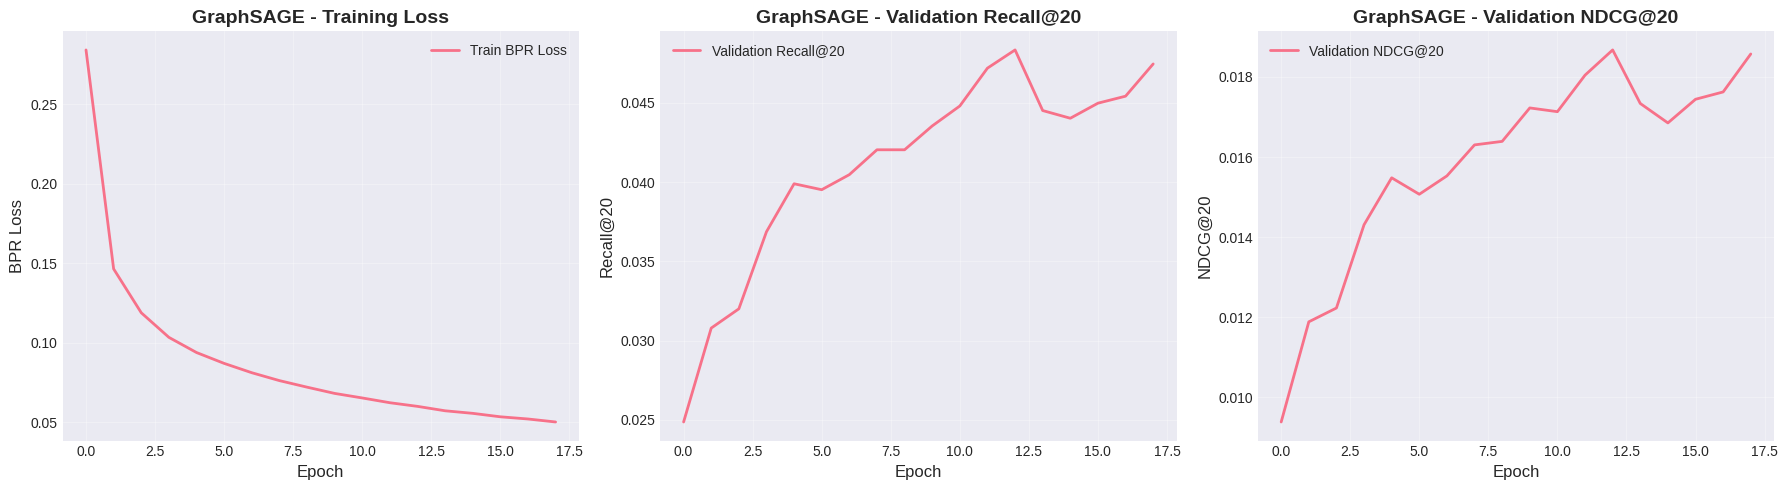

In [29]:
# Plot GraphSAGE ranking training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses_sage, label='Train BPR Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('BPR Loss', fontsize=12)
axes[0].set_title('GraphSAGE - Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_recalls_sage, label=f'Validation Recall@{TOP_K}', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel(f'Recall@{TOP_K}', fontsize=12)
axes[1].set_title(f'GraphSAGE - Validation Recall@{TOP_K}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(val_ndcgs_sage, label=f'Validation NDCG@{TOP_K}', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel(f'NDCG@{TOP_K}', fontsize=12)
axes[2].set_title(f'GraphSAGE - Validation NDCG@{TOP_K}', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Model Comparison and Results

In [30]:
# Ranking result summary
print("=" * 80)
print("MAIN RANKING RESULT - GRAPHSAGE")
print("=" * 80)

ranking_results = pd.DataFrame({
    'Model': ['GraphSAGE'],
    'Task': ['Top-K Ranking'],
    'K-Core': [K_CORE],
    'K': [TOP_K],
    f'Test Recall@{TOP_K}': [test_recall_sage],
    f'Test NDCG@{TOP_K}': [test_ndcg_sage],
})

print(ranking_results.to_string(index=False))
print("=" * 80)

print("\nNote:")
print("- The earlier MF / Two-Tower / LightGCN sections are kept in the notebook.")
print("- This final section focuses on the requested GraphSAGE ranking setup.")
print("- Change K_CORE near the preprocessing section to run k-core ablations.")
print("- Change TOP_K near the preprocessing section to evaluate different K values.")


MAIN RANKING RESULT - GRAPHSAGE
    Model          Task  K-Core  K  Test Recall@20  Test NDCG@20
GraphSAGE Top-K Ranking      15 20        0.037153      0.014009

Note:
- The earlier MF / Two-Tower / LightGCN sections are kept in the notebook.
- This final section focuses on the requested GraphSAGE ranking setup.
- Change K_CORE near the preprocessing section to run k-core ablations.
- Change TOP_K near the preprocessing section to evaluate different K values.


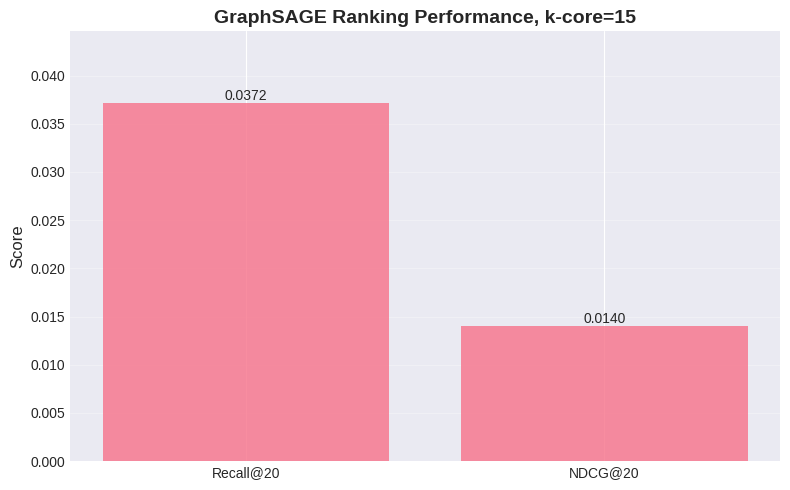

In [31]:
# Visualize GraphSAGE ranking test metrics
metrics = [f'Recall@{TOP_K}', f'NDCG@{TOP_K}']
values = [test_recall_sage, test_ndcg_sage]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, alpha=0.8)
plt.ylabel('Score', fontsize=12)
plt.title(f'GraphSAGE Ranking Performance, k-core={K_CORE}', fontsize=14, fontweight='bold')
plt.ylim(0, max(values) * 1.2 if max(values) > 0 else 1)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()
